# Project 4: Data Visualization Dashboard
**Intern:** Mudassar Abbas  
**Organization:** DecodeLabs  
**Track:** Data Analytics | **Batch:** 2026  

---
## Objective
Build a comprehensive data visualization dashboard using Matplotlib and Seaborn to present business insights from the Customer Sales dataset in a clear, professional, and stakeholder-ready format.

---

## Step 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except:
    pass

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('cleaned_customer_data.csv')
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])
df['Month'] = df['Purchase_Date'].dt.strftime('%b %Y')
df['Month_Num'] = df['Purchase_Date'].dt.to_period('M')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (29, 10)


,Customer_ID,Customer_Name,Age,City,Purchase_Date,Revenue,Product_Category,Status,Month,Month_Num
0,C001,Ali Khan,25,Lahore,2024-01-15,1500.50,Electronics,Active,Jan 2024,2024-01
1,C002,Sara Ahmed,28,Karachi,2024-02-15,2300.00,Clothing,Active,Feb 2024,2024-02
2,C003,Bilal Raza,30,Lahore,2024-03-20,1900.50,Electronics,Active,Mar 2024,2024-03
3,C004,Usman Malik,22,Islamabad,2024-04-20,800.75,Clothing,Active,Apr 2024,2024-04
4,C005,Zara Sheikh,28,Karachi,2024-05-10,1200.00,Electronics,Active,May 2024,2024-05


## Step 2: Chart 1 — Revenue by Product Category (Bar Chart)

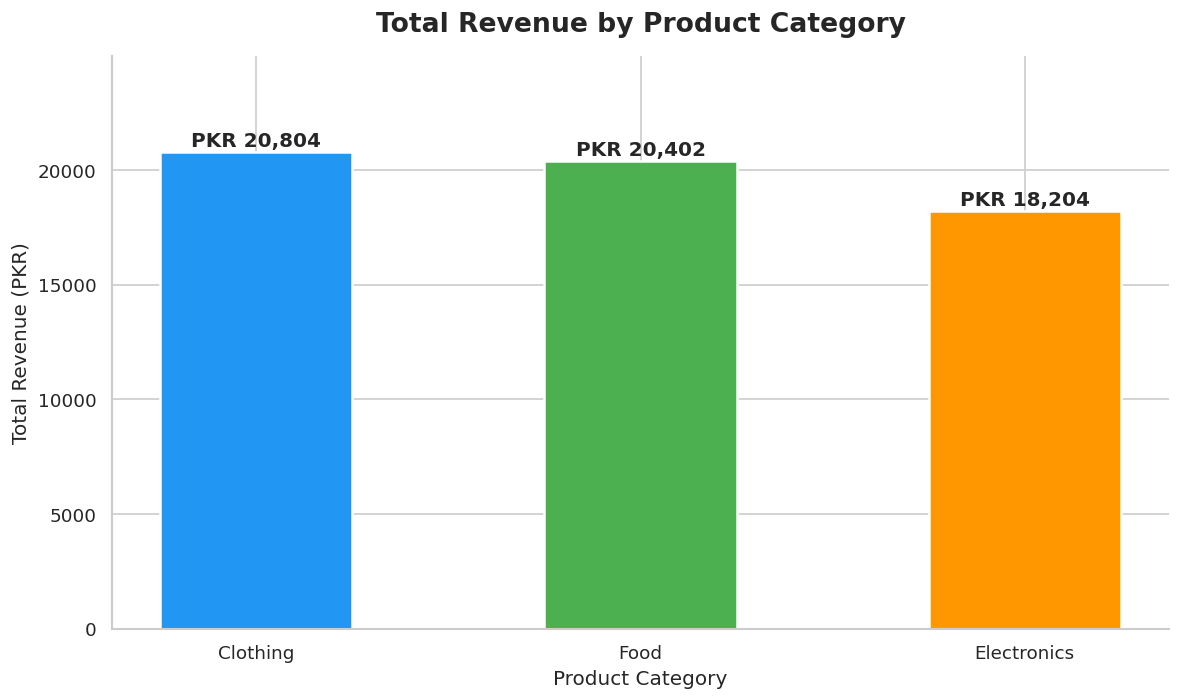

Insight: Clothing leads all categories in total revenue.


In [2]:
cat_data = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(cat_data.index, cat_data.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, cat_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'PKR {val:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Total Revenue by Product Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Total Revenue (PKR)', fontsize=12)
ax.set_ylim(0, cat_data.max() * 1.2)
plt.tight_layout()
plt.savefig('chart1_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Clothing leads all categories in total revenue.')

## Step 3: Chart 2 — Revenue Trend Over Time (Line Chart)

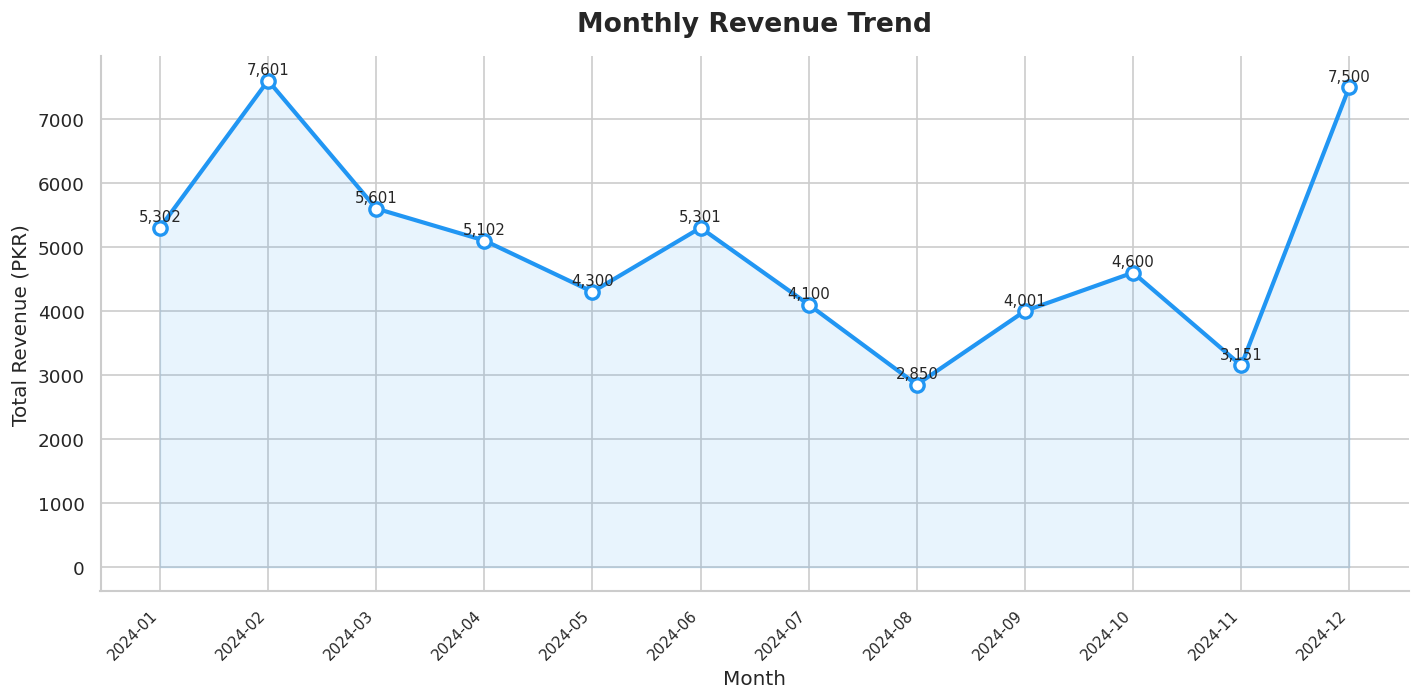

Insight: Revenue shows variation across months — peak and low months identified.


In [3]:
monthly = df.groupby('Month_Num')['Revenue'].sum().reset_index()
monthly['Month_Num'] = monthly['Month_Num'].astype(str)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly['Month_Num'], monthly['Revenue'], color='#2196F3',
        linewidth=2.5, marker='o', markersize=8, markerfacecolor='white',
        markeredgecolor='#2196F3', markeredgewidth=2)
ax.fill_between(range(len(monthly)), monthly['Revenue'], alpha=0.1, color='#2196F3')

for i, (x, y) in enumerate(zip(range(len(monthly)), monthly['Revenue'])):
    ax.text(x, y + 50, f'{y:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Month_Num'], rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Revenue (PKR)', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Revenue shows variation across months — peak and low months identified.')

## Step 4: Chart 3 — Customer Distribution by City (Pie Chart)

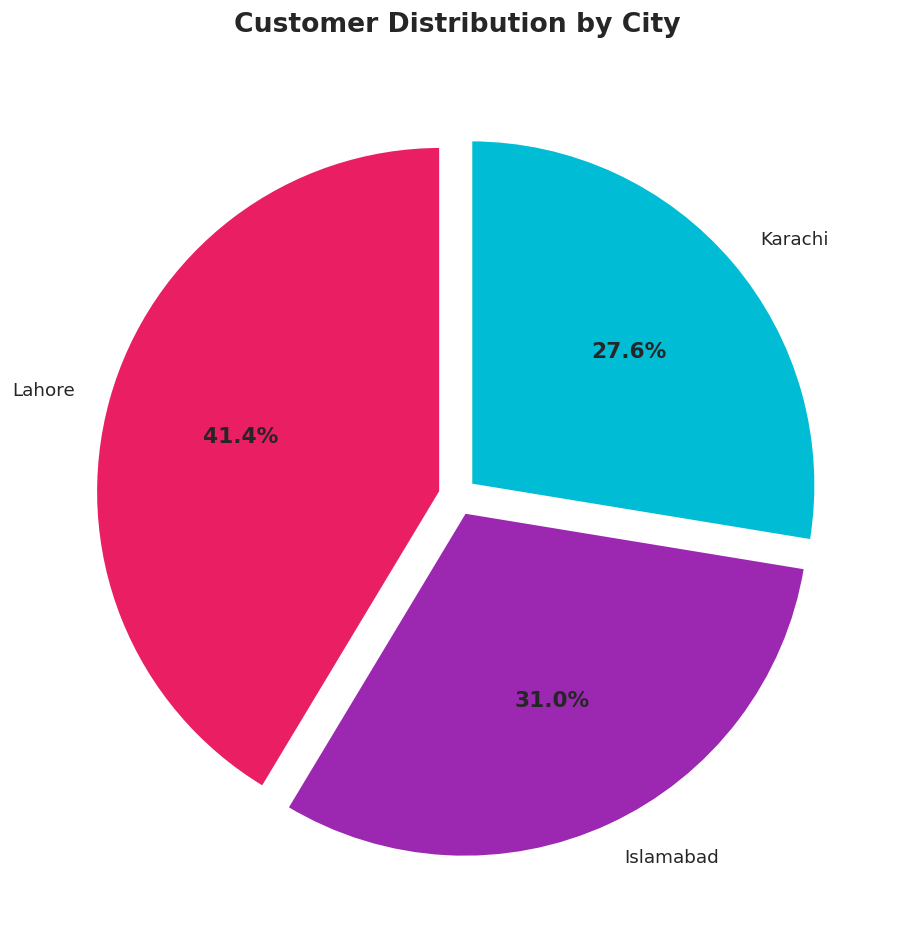

Insight: Lahore has the largest customer base.


In [4]:
city_counts = df['City'].value_counts()
city_colors = ['#E91E63', '#9C27B0', '#00BCD4']
explode = [0.05] * len(city_counts)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    city_counts.values,
    labels=city_counts.index,
    autopct='%1.1f%%',
    colors=city_colors,
    explode=explode,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

ax.set_title('Customer Distribution by City', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart3_city_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Lahore has the largest customer base.')

## Step 5: Chart 4 — Age vs Revenue (Scatter Plot)

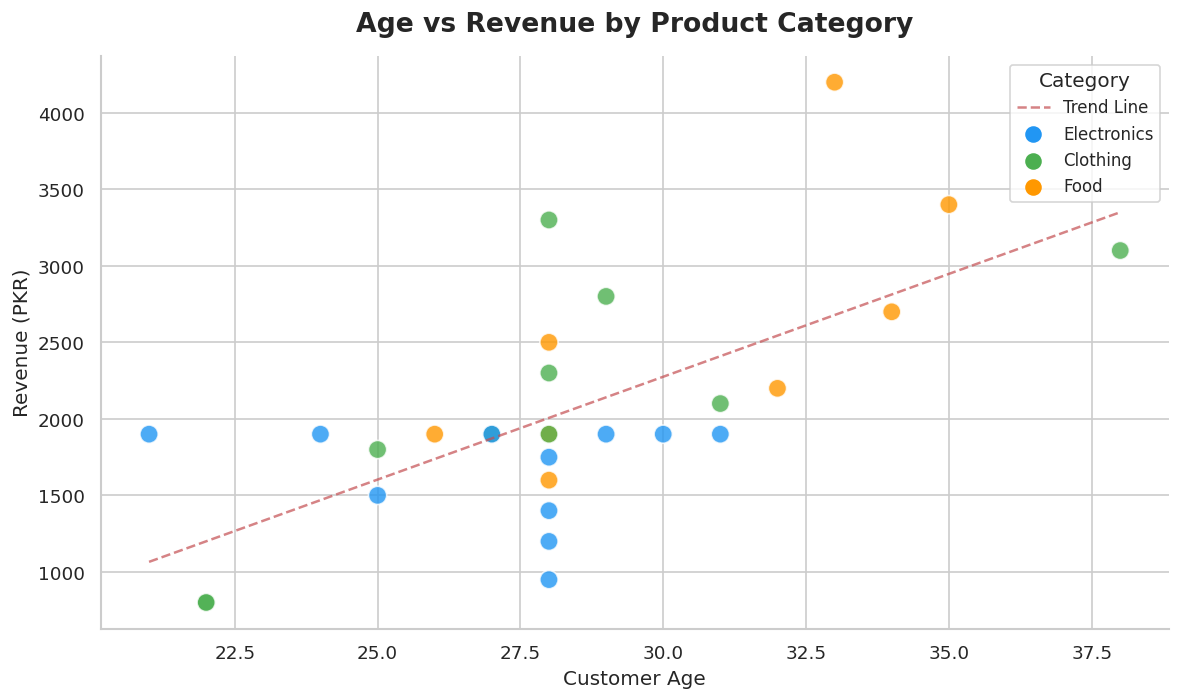

Insight: No strong correlation between age and revenue — all age groups spend similarly.


In [5]:
category_colors = {'Electronics': '#2196F3', 'Clothing': '#4CAF50', 'Food': '#FF9800'}
colors_mapped = df['Product_Category'].map(category_colors)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['Age'], df['Revenue'], c=colors_mapped,
                     s=120, alpha=0.8, edgecolors='white', linewidth=1)

# Add trend line
z = np.polyfit(df['Age'], df['Revenue'], 1)
p = np.poly1d(z)
ax.plot(sorted(df['Age']), p(sorted(df['Age'])), 'r--', alpha=0.7, linewidth=1.5, label='Trend Line')

# Legend
for cat, col in category_colors.items():
    ax.scatter([], [], c=col, label=cat, s=80)
ax.legend(title='Category', fontsize=10)

ax.set_title('Age vs Revenue by Product Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Customer Age', fontsize=12)
ax.set_ylabel('Revenue (PKR)', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_age_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: No strong correlation between age and revenue — all age groups spend similarly.')

## Step 6: Chart 5 — Revenue by City & Category (Grouped Bar)

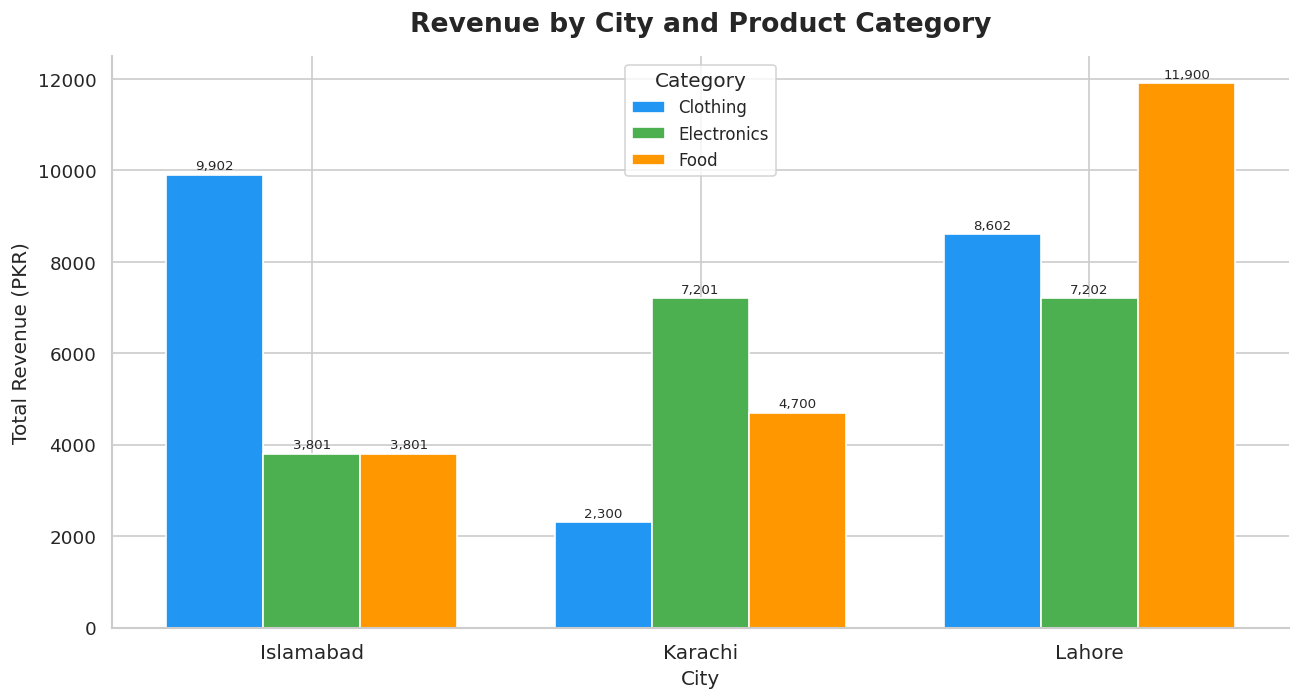

Insight: Food drives revenue in Lahore; Clothing is strong across all cities.


In [6]:
pivot = df.groupby(['City', 'Product_Category'])['Revenue'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(pivot.index))
width = 0.25
bar_colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (col, color) in enumerate(zip(pivot.columns, bar_colors)):
    bars = ax.bar(x + i*width, pivot[col], width, label=col, color=color,
                  edgecolor='white', linewidth=1)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 50,
                    f'{h:,.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(pivot.index, fontsize=12)
ax.set_title('Revenue by City and Product Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Total Revenue (PKR)', fontsize=12)
ax.legend(title='Category', fontsize=10)
plt.tight_layout()
plt.savefig('chart5_city_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Food drives revenue in Lahore; Clothing is strong across all cities.')

## Step 7: Chart 6 — Revenue Distribution Boxplot by Category

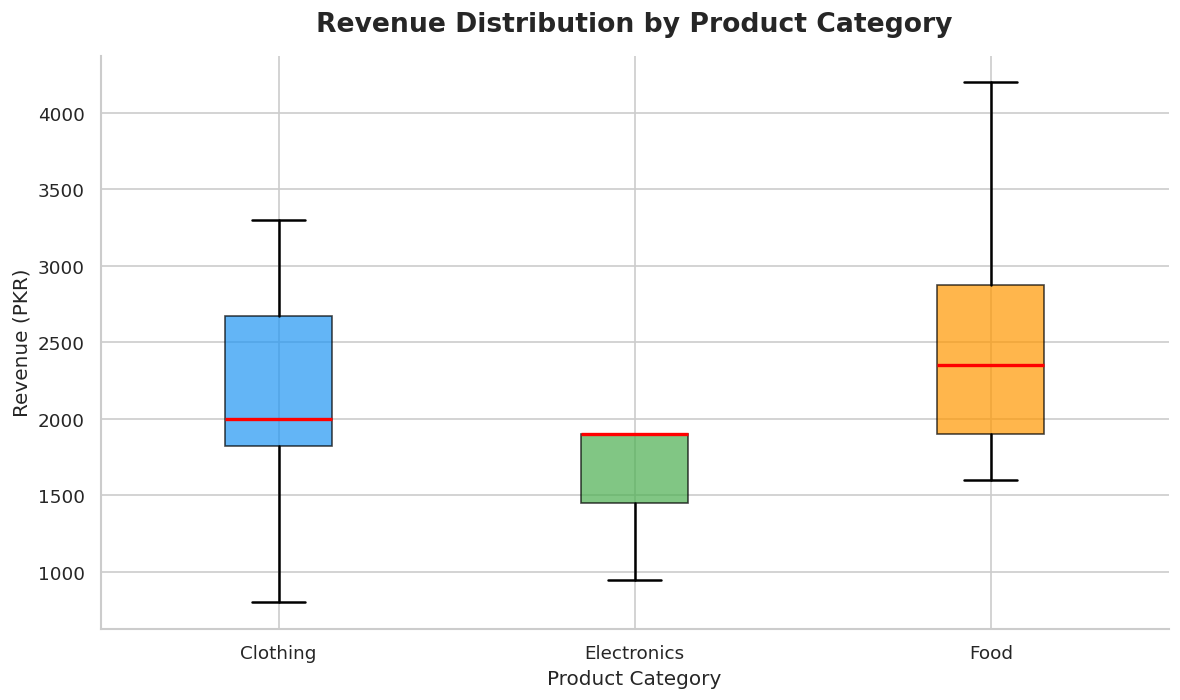

Insight: Food category shows highest spread — more high-value purchases.


In [7]:
categories = df['Product_Category'].unique()
data_by_cat = [df[df['Product_Category']==cat]['Revenue'].values for cat in sorted(categories)]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(data_by_cat, labels=sorted(categories), patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

box_colors = ['#2196F3', '#4CAF50', '#FF9800']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Revenue Distribution by Product Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Revenue (PKR)', fontsize=12)
plt.tight_layout()
plt.savefig('chart6_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Food category shows highest spread — more high-value purchases.')

## Step 8: Chart 7 — Active vs Inactive Customers (Horizontal Bar)

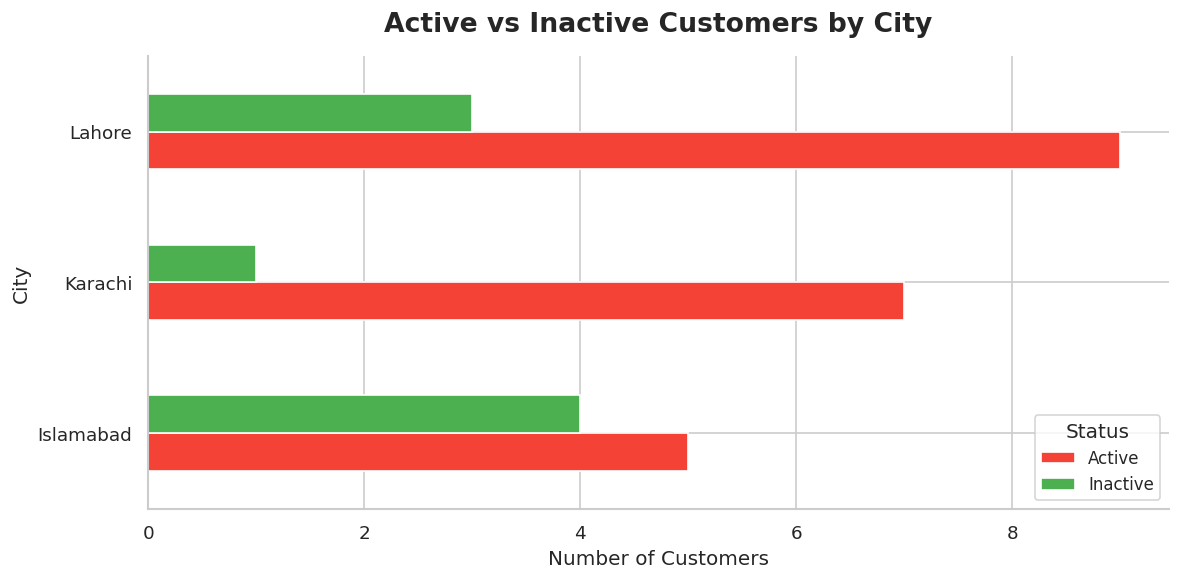

Insight: All cities show majority Active customers — good retention.


In [8]:
status_city = df.groupby(['City', 'Status'])['Customer_ID'].count().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
status_city.plot(kind='barh', ax=ax, color=['#F44336', '#4CAF50'],
                 edgecolor='white', linewidth=1)

ax.set_title('Active vs Inactive Customers by City', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Customers', fontsize=12)
ax.set_ylabel('City', fontsize=12)
ax.legend(title='Status', fontsize=10)
plt.tight_layout()
plt.savefig('chart7_status_city.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: All cities show majority Active customers — good retention.')

## Step 9: Final Dashboard — All Key Metrics in One View

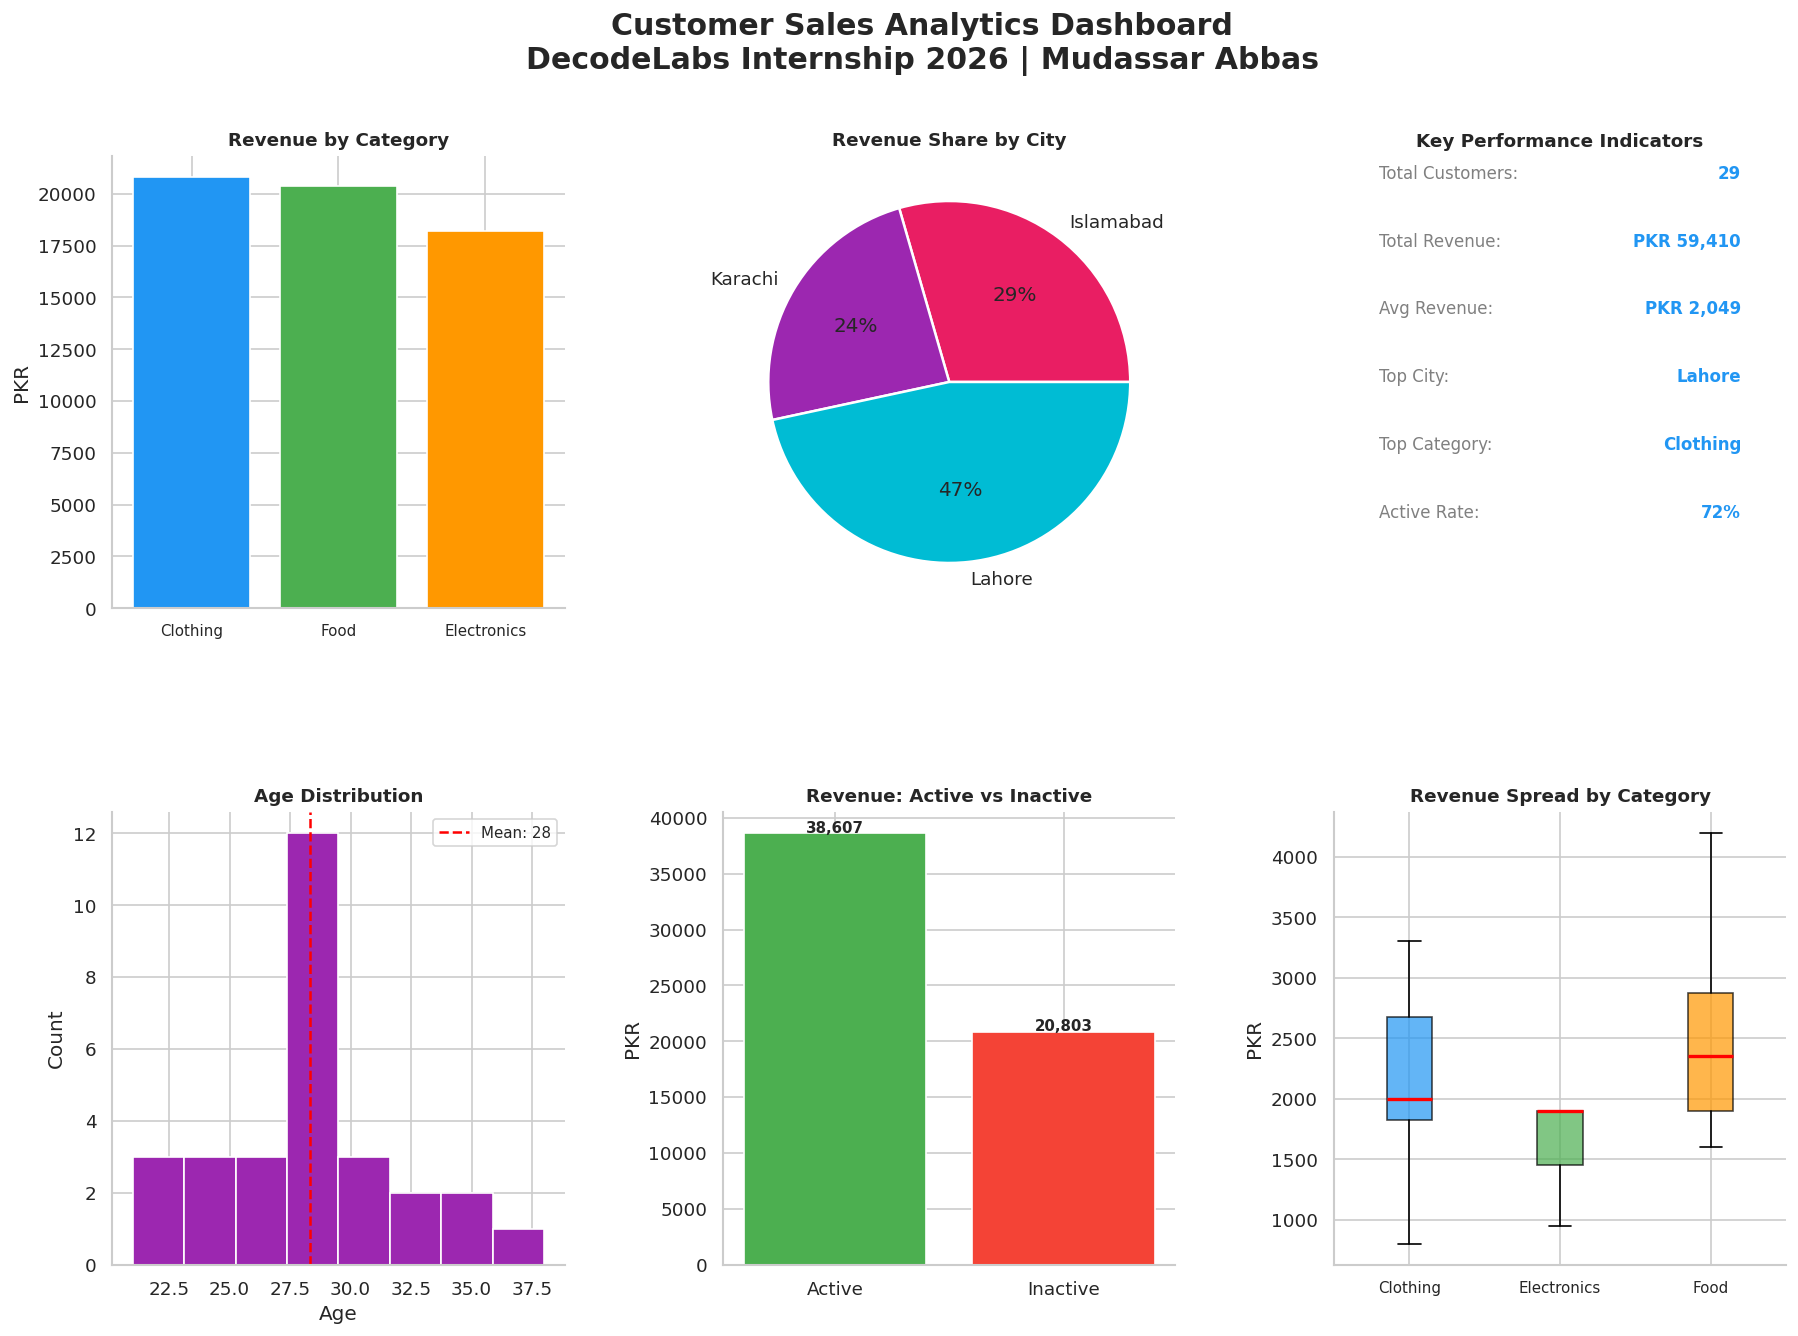

Final Dashboard saved!


In [9]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Customer Sales Analytics Dashboard\nDecodeLabs Internship 2026 | Mudassar Abbas',
             fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1 - Category Revenue
ax1 = fig.add_subplot(gs[0, 0])
cat_data = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)
ax1.bar(cat_data.index, cat_data.values, color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
ax1.set_title('Revenue by Category', fontweight='bold', fontsize=11)
ax1.set_ylabel('PKR')
ax1.tick_params(axis='x', labelsize=9)

# Panel 2 - City Pie
ax2 = fig.add_subplot(gs[0, 1])
city_rev = df.groupby('City')['Revenue'].sum()
ax2.pie(city_rev.values, labels=city_rev.index, autopct='%1.0f%%',
        colors=['#E91E63','#9C27B0','#00BCD4'],
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title('Revenue Share by City', fontweight='bold', fontsize=11)

# Panel 3 - KPI Summary
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
kpis = [
    ('Total Customers', str(len(df))),
    ('Total Revenue', f'PKR {df["Revenue"].sum():,.0f}'),
    ('Avg Revenue', f'PKR {df["Revenue"].mean():,.0f}'),
    ('Top City', df.groupby("City")["Revenue"].sum().idxmax()),
    ('Top Category', df.groupby("Product_Category")["Revenue"].sum().idxmax()),
    ('Active Rate', f'{(df["Status"]=="Active").mean()*100:.0f}%')
]
y_pos = 0.95
ax3.text(0.5, 1.05, 'Key Performance Indicators', ha='center', va='top',
         fontsize=11, fontweight='bold', transform=ax3.transAxes)
for label, value in kpis:
    ax3.text(0.1, y_pos, label+':', fontsize=10, transform=ax3.transAxes, color='gray')
    ax3.text(0.9, y_pos, value, fontsize=10, fontweight='bold',
             transform=ax3.transAxes, ha='right', color='#2196F3')
    y_pos -= 0.15

# Panel 4 - Age Histogram
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df['Age'], bins=8, color='#9C27B0', edgecolor='white')
ax4.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean: {df["Age"].mean():.0f}')
ax4.set_title('Age Distribution', fontweight='bold', fontsize=11)
ax4.set_xlabel('Age')
ax4.set_ylabel('Count')
ax4.legend(fontsize=9)

# Panel 5 - Status Bar
ax5 = fig.add_subplot(gs[1, 1])
status_rev = df.groupby('Status')['Revenue'].sum()
ax5.bar(status_rev.index, status_rev.values,
        color=['#4CAF50','#F44336'], edgecolor='white')
ax5.set_title('Revenue: Active vs Inactive', fontweight='bold', fontsize=11)
ax5.set_ylabel('PKR')
for i, v in enumerate(status_rev.values):
    ax5.text(i, v + 100, f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Panel 6 - Revenue Boxplot
ax6 = fig.add_subplot(gs[1, 2])
categories = sorted(df['Product_Category'].unique())
data_by_cat = [df[df['Product_Category']==cat]['Revenue'].values for cat in categories]
bp = ax6.boxplot(data_by_cat, labels=categories, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2))
box_colors2 = ['#2196F3', '#4CAF50', '#FF9800']
for patch, color in zip(bp['boxes'], box_colors2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax6.set_title('Revenue Spread by Category', fontweight='bold', fontsize=11)
ax6.set_ylabel('PKR')
ax6.tick_params(axis='x', labelsize=9)

plt.savefig('dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final Dashboard saved!')

## Step 10: Key Findings & Observations

In [10]:
print('=' * 55)
print('   DATA VISUALIZATION — KEY FINDINGS')
print('=' * 55)
print()
print(f'[1] REVENUE: Total PKR {df["Revenue"].sum():,.2f} across {len(df)} customers')
top_cat = df.groupby('Product_Category')['Revenue'].sum().idxmax()
top_city = df.groupby('City')['Revenue'].sum().idxmax()
print(f'[2] TOP CATEGORY: {top_cat} generates highest total revenue')
print(f'[3] TOP CITY: {top_city} is the strongest market')
print(f'[4] AVERAGE REVENUE: PKR {df["Revenue"].mean():,.2f} per customer')
print(f'[5] ACTIVE CUSTOMERS: {(df["Status"]=="Active").sum()} out of {len(df)} ({(df["Status"]=="Active").mean()*100:.0f}%)')
print(f'[6] AGE INSIGHT: Most customers are between 25-35 years old')
print(f'[7] SPREAD: Food category shows highest revenue variability (outliers present)')
print()
print('BUSINESS RECOMMENDATION:')
print(f'Focus marketing budget on {top_city} + {top_cat} combination')
print('for maximum return on investment.')

   DATA VISUALIZATION — KEY FINDINGS

[1] REVENUE: Total PKR 59,409.75 across 29 customers
[2] TOP CATEGORY: Clothing generates highest total revenue
[3] TOP CITY: Lahore is the strongest market
[4] AVERAGE REVENUE: PKR 2,048.61 per customer
[5] ACTIVE CUSTOMERS: 21 out of 29 (72%)
[6] AGE INSIGHT: Most customers are between 25-35 years old
[7] SPREAD: Food category shows highest revenue variability (outliers present)

BUSINESS RECOMMENDATION:
Focus marketing budget on Lahore + Clothing combination
for maximum return on investment.


---
## Visualization Summary

| Chart | Type | Business Question |
|-------|------|------------------|
| Chart 1 | Bar Chart | Which category earns most? |
| Chart 2 | Line Chart | How does revenue trend over time? |
| Chart 3 | Pie Chart | How are customers distributed by city? |
| Chart 4 | Scatter Plot | Does age affect spending? |
| Chart 5 | Grouped Bar | Which city+category combination leads? |
| Chart 6 | Box Plot | How spread is revenue per category? |
| Chart 7 | Horizontal Bar | Active vs Inactive by city |
| Dashboard | Multi-panel | Complete business overview |

---
**Intern:** Mudassar Abbas | **DecodeLabs Data Analytics Internship 2026**